In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib.transforms import blended_transform_factory

# %matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import warnings
warnings.simplefilter("ignore")

pd.set_option('display.precision', 1)

def get_missing_combinations(
    df,
    x_col,
    hue_col,
    y_col,
    x_order=None,
    hue_order=None,
):
    """
    Return missing (x, hue) combinations after filtering rows with missing y values.
    """
    plot_df = df.dropna(subset=[y_col]).copy()

    if x_order is None:
        x_order = sorted(df[x_col].dropna().unique())
    if hue_order is None:
        hue_order = list(df[hue_col].dropna().unique())

    expected = pd.MultiIndex.from_product(
        [x_order, hue_order],
        names=[x_col, hue_col]
    )

    present = (
        plot_df[[x_col, hue_col]]
        .dropna()
        .drop_duplicates()
        .set_index([x_col, hue_col])
        .index
    )

    missing = expected.difference(present)
    return plot_df, list(x_order), list(hue_order), missing


def add_missing_x_markers(
    ax,
    missing,
    x_order,
    hue_order,
    y_fraction=0.035,
    marker="x",
    color="red",
    markersize=7,
    markeredgewidth=2,
    group_width=0.8,
):
    """
    Plot markers at missing (x, hue) positions for a seaborn categorical plot.
    """
    if len(missing) == 0:
        return

    n_hue = len(hue_order)
    step = group_width / n_hue

    transform = blended_transform_factory(
        ax.transData,
        ax.transAxes,
    )

    for x_val, hue_val in missing:
        x_center = x_order.index(x_val)
        hue_index = hue_order.index(hue_val)

        x_pos = (
            x_center
            - group_width / 2
            + step / 2
            + hue_index * step
        )

        ax.plot(
            x_pos,
            y_fraction,
            marker=marker,
            color=color,
            markersize=markersize,
            markeredgewidth=markeredgewidth,
            linestyle="none",
            transform=transform,
            zorder=20,
            clip_on=False,
        )


def color_missing_legend_labels(
    legend,
    missing,
    color="red",
):
    """
    Color legend text for hue labels that appear in any missing (x, hue) combination.
    """
    missing_hues = {hue for _, hue in missing}

    for text in legend.get_texts():
        if text.get_text() in missing_hues:
            text.set_color(color)


def load_pynndescent(df_all):
    paths = {
        "pynndescent": "../tests/results/pynndescent",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]

            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("pynndescent")
                df["dataset"] = filename[14:end-4]
                df["version"] = "pynndescent"

            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)

            # display(df_config)
        else:
            print("Does not exist")

    return df_all

def load_faiss(df_all):
    paths = {
        "HNSW": "../tests/results/faiss_HNSW",
        "IVF": "../tests/results/faiss_IVF",
        "LSH": "../tests/results/faiss_LSH_1bit",
        "IVFPQ": "../tests/results/faiss_IVFPQ_nbits_4",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("faiss_backend")
                df["dataset"] = filename[14:end-4]
                # print(filename[14:end-4])
                df["version"] = name

            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)

            # display(df_config)
        else:
            print("Does not exist")

    return df_all



def load_latentmotifs(df_all):
    paths = {
        "latentmotifs": "../tests/results/latentmotifs_converted",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("latentmotifs")
                df["dataset"] = filename[14:end-4]

                df["version"] = name
                df["backend"] = name
                # print(filename[14:end-4])
                df["extent"] = np.nan
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)

            # display(df_config)
        else:
            print("Does not exist")

    return df_all


def load_momp(df_all):
    paths = {
        "MOMP": "../tests/results/momp",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                df["dataset"] = filename[5:len(filename)-4]
                df["version"] = name
                df["memory in MB"] = np.nan

            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
    
            # display(df_config)
        else:
            print("Does not exist")

    return df_all


def load_scalable(df_all):
    paths = {
        "exact_sub": "../tests/results/exact_sub",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                factor = key.split("_")[-1][:-4]
                filename = os.path.basename(key)
                end = filename.find("scalable")
                df["dataset"] = filename[14:end-4]
                df["version"] = "MASS / PAA " + key.split("_")[-1][:-4]
                df["sampling"] = key.split("_")[-1][:-4]

            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
        else:
            print("Does not exist")

    return df_all


def load_scampi(df_all):
    paths = {
        "SCAMPI" : "../tests/results/scampi_8GB",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]

            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("scampi")
                df["dataset"] = filename[14:end-4]

            df_config = pd.concat(dfs, ignore_index=True)
            df_config["version"] = name
            df_config["backend"] = name

            df_config["extent"] = df_config["extent"] # .apply(lambda l : l[-1])
            df_config["motiflet"] = df_config["motiflet"] # .apply(lambda l : l[-1])

            # df_config.info()
            # display(df_config)

            df_all = pd.concat([df_all, df_config], ignore_index=True)
        else:
            print("Does not exist")

    return df_all

df_all = pd.DataFrame()
df_all = load_scampi(df_all)
df_all = load_scalable(df_all)
df_all = load_faiss(df_all)
df_all = load_pynndescent(df_all)
df_all = load_latentmotifs(df_all)
df_all = load_momp(df_all)

# not enough data from all datasets for l=8192
df_all = df_all[df_all["motif length"] <= 4096]
df_all["extent"] = np.sqrt(df_all["extent"])

df_all.loc[df_all.version == "latentmotifs_2r", "version"] = "LM 2"
df_all.loc[df_all.version == "latentmotifs", "version"] = "LM"
df_all.loc[df_all.version == "scampi 8GB", "version"] = "SCAMPI"
df_all.loc[df_all.version == "attimo", "version"] = "ATTIMO"
df_all.loc[df_all.version == "IVFPQ", "version"] = "FAISS (IVFPQ)"
df_all.loc[df_all.version == "HNSW", "version"] = "FAISS (HNSW)"
df_all.loc[df_all.version == "LSH", "version"] = "FAISS (LSH)"
df_all.loc[df_all.version == "IVF", "version"] = "FAISS (IVF)"
df_all.loc[df_all.version == "IVFPQ", "version"] = "FAISS (IVFPQ)"
df_all.loc[df_all.version == "pynndescent", "version"] = "pynndescent"
df_all.loc[df_all.version == "exact (projected)", "version"] = "Exact$^*$"

# MASS / Exact*
subset = df_all.loc[df_all.version == "MASS / PAA 16"].copy()
subset.loc[subset.version == "MASS / PAA 16", "time in s"] *= 16**2
subset.loc[subset.version == "MASS / PAA 16", "extent"] *= np.nan
subset.loc[subset.version == "MASS / PAA 16", "memory in MB"] *= np.nan
subset.loc[subset.version == "MASS / PAA 16", "version"] = "Exact$^*$"
subset.loc[subset.version == "MASS / PAA 16", "backend"] = "Exact$^*$"
df_all = pd.concat([df_all, subset], ignore_index=True)


display(pd.DataFrame(df_all.version.unique()))

Reading from../tests/results/scampi_8GB
Reading from../tests/results/exact_sub
Reading from../tests/results/faiss_HNSW
Reading from../tests/results/faiss_IVF
Reading from../tests/results/faiss_LSH_1bit
Reading from../tests/results/faiss_IVFPQ_nbits_4
Reading from../tests/results/pynndescent
Reading from../tests/results/latentmotifs_converted
Reading from../tests/results/momp


,0
0,SCAMPI
1,MASS / PAA 8
2,MASS / PAA 32
3,MASS / PAA 64
4,MASS / PAA 16
5,FAISS (HNSW)
6,FAISS (IVF)
7,FAISS (LSH)
8,FAISS (IVFPQ)
9,pynndescent


In [2]:
print("Total number of datasets:    ", df_all.dataset.unique().shape[0])

# Filter
counts = df_all.groupby(["dataset", "version"]).size()
counts_df = counts.reset_index(name='count')

count_versions = df_all.version.nunique()

# filter datasets where not all indices ran
def all_counts_equal(group):
    return group['version'].nunique() >= count_versions-2 # & (group['count'].min() >= 4)

datasets_to_keep = counts_df.groupby('dataset').filter(all_counts_equal)['dataset'].unique()
print("Filtered number of datasets: ", datasets_to_keep.shape[0])

filtered_df = df_all[df_all["dataset"].isin(datasets_to_keep)]
filtered_df = filtered_df[filtered_df["motif length"] <= 4096]

custom_order = ["SCAMPI",
                "FAISS (HNSW)",
                "FAISS (LSH)",
                "FAISS (IVF)",
                "FAISS (IVFPQ)",
                "pynndescent",
                "MOMP",
                "LM",
                "Exact$^*$"                
               ]

filtered_df = filtered_df[filtered_df.version.isin(custom_order)].copy()
filtered_df = filtered_df[filtered_df.length < 10_000_000]

display(pd.DataFrame(filtered_df.version.unique()).T)
display(pd.DataFrame(filtered_df.dataset.unique()))

Total number of datasets:     24
Filtered number of datasets:  20


,0,1,2,3,4,5,6,7,8
0,SCAMPI,FAISS (HNSW),FAISS (IVF),FAISS (LSH),FAISS (IVFPQ),pynndescent,LM,MOMP,Exact$^*$


,0
0,HAR_Ambient_Sensor_Data
1,EOG_one_hour_400_Hz
2,CinC_Challenge
3,water
4,Challenge2009Respiration500HZ
5,Challenge2009TestSetA_101a
6,BlackLeggedKittiwake
7,Lab_K_060314
8,SpainishEnergyDataset
9,stator_winding


In [3]:
unique_versions = filtered_df['version'].unique()  # Or your full df if needed
version_order = [
    'SCAMPI',
    'Exact$^*$',
    'FAISS (HNSW)', 'FAISS (IVF)', 'FAISS (IVFPQ)', 'FAISS (LSH)',
    'pynndescent',
    'MOMP',
    'LM']
n_versions = len(version_order)

print(unique_versions)

['SCAMPI' 'FAISS (HNSW)' 'FAISS (IVF)' 'FAISS (LSH)' 'FAISS (IVFPQ)'
 'pynndescent' 'LM' 'MOMP' 'Exact$^*$']


In [4]:
eps = 1e-2
group_cols = ["dataset", "motif length"]

filtered_df = filtered_df.copy()

filtered_df["extent_clean"] = (
    filtered_df["extent"]
    .replace([np.inf, -np.inf], np.nan)
)

filtered_df["best_extent"] = (
    filtered_df.groupby(group_cols)["extent_clean"].transform("min")
)

filtered_df["worst_extent"] = (
    filtered_df.groupby(group_cols)["extent_clean"].transform("max")
)

denom = filtered_df["worst_extent"] - filtered_df["best_extent"]

# 100 = best / lowest extent
# 0   = worst / highest extent
filtered_df["relative extent"] = np.where(
    filtered_df["extent_clean"].isna(),
    np.nan,
    np.where(
        denom > 0,
        100
        * (
            filtered_df["worst_extent"]
            - filtered_df["extent_clean"]
        )
        / denom,
        np.where(denom == 0, 100, np.nan),
    ),
)

# Rank within each dataset / motif-length group:
# 1 = best / lowest extent
filtered_df["extent rank"] = (
    filtered_df.groupby(group_cols)["extent_clean"]
    .rank(method="dense", ascending=True)  # , na_option="bottom"
)


time = (
    filtered_df.dropna(subset=["time in s"])
    .groupby("version")
    .agg({"time in s": "sum"})
    .div(3600)
    .rename(columns={"time in s": "time in hours"})
)

filtered_df["memory in GiB"] = filtered_df["memory in MB"] / 1024

extent = filtered_df.groupby("version").agg(
    {
        "dataset": ["nunique"],
        "relative extent": ["mean"],
        "extent rank": ["mean"],
        "memory in GiB": ["mean", "median"],
    }
).rename(
    columns={"nunique": "count"},
    level=1,
)

extent["time in h"] = time["time in hours"]

df_display =   extent.sort_values(
        ("extent rank", "mean"),
        ascending=True,
    ).style.format(
        {
            ("relative extent", "mean"): "{:.1f}%",
            ("extent rank", "mean"): "{:.1f}",
            ("memory in GiB", "mean"): "{:.1f}",
            ("memory in GiB", "median"): "{:.1f}",
            ("time in hours", "mean"): "{:.1f}",
            ("time in h", ""): "{:.1f}",
            ("dataset", "count"): "{:.0f}",
        },
        na_rep="-",
    )

display(df_display)

In [5]:
print(df_display.to_latex())

\begin{tabular}{lrrrrrr}
 & dataset & relative extent & extent rank & \multicolumn{2}{r}{memory in GiB} & time in h \\
 & count & mean & mean & mean & median &  \\
version &  &  &  &  &  &  \\
SCAMPI & 19 & 93.0% & 1.7 & 8.9 & 8.9 & 2.0 \\
pynndescent & 19 & 85.2% & 2.4 & 195.7 & 102.6 & 162.0 \\
FAISS (HNSW) & 19 & 88.6% & 2.4 & 111.7 & 62.2 & 95.5 \\
FAISS (IVF) & 19 & 85.1% & 2.6 & 122.0 & 72.1 & 182.0 \\
FAISS (IVFPQ) & 19 & 79.6% & 3.0 & 85.9 & 48.9 & 15.2 \\
FAISS (LSH) & 19 & 78.2% & 3.0 & 70.6 & 45.6 & 212.3 \\
MOMP & 18 & 23.5% & 4.5 & - & - & 453.7 \\
Exact$^*$ & 19 & - & - & - & - & 1338.0 \\
LM & 18 & - & - & 52.7 & 28.4 & 210.7 \\
\end{tabular}



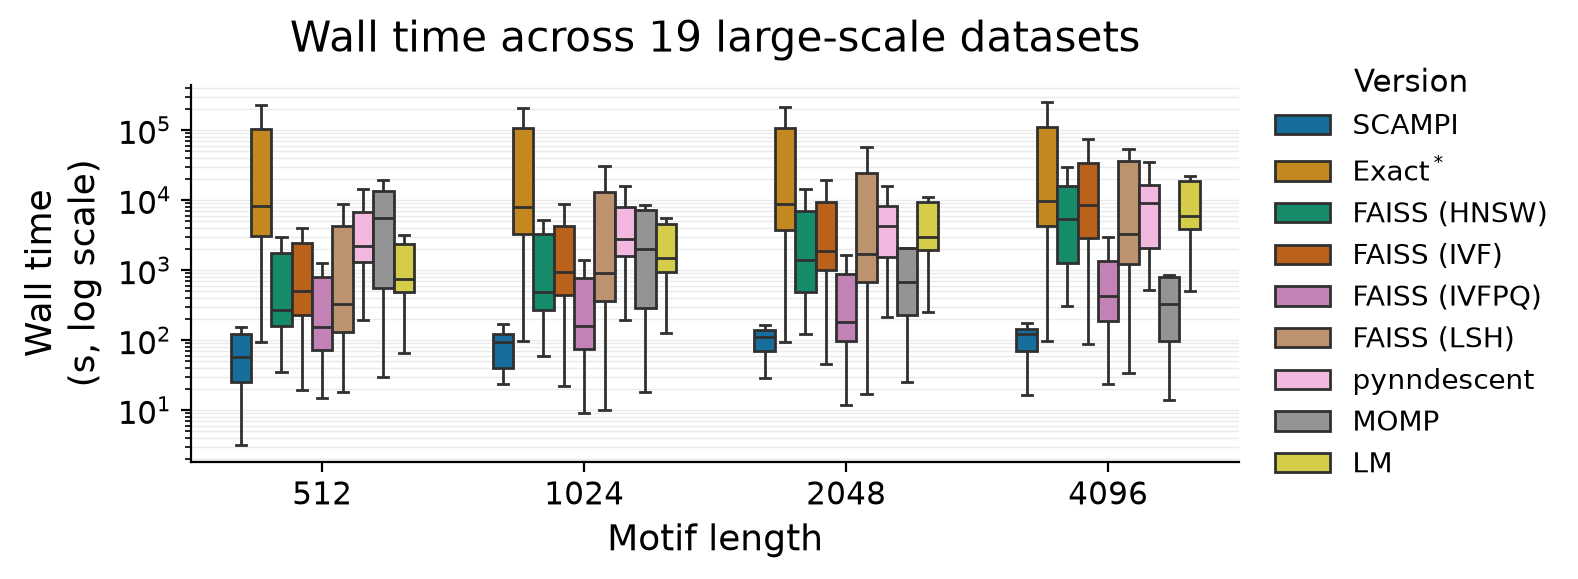

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_df, all_x, all_versions, missing = get_missing_combinations(
    df=filtered_df,
    x_col="motif length",
    hue_col="version",
    y_col="time in s",
    x_order=sorted(filtered_df["motif length"].dropna().unique()),
    hue_order=version_order,
)

# Create this once and reuse it for every plot
base_palette = sns.color_palette(
    "colorblind",
    n_colors=len(all_versions),
)

version_colors = dict(zip(all_versions, base_palette))

box_width = 0.7

sns.boxplot(
    data=plot_df,
    x="motif length",
    y="time in s",
    hue="version",
    order=all_x,
    hue_order=all_versions,
    # palette=palette,
    palette=version_colors,
    width=box_width,
    linewidth=1.0,
    showfliers=False,
    ax=ax,
)


ax.set_yscale("log")
ax.set_xlabel("Motif length", fontsize=13)
ax.set_ylabel("Wall time\n(s, log scale)", fontsize=13)

n_datasets = filtered_df["dataset"].nunique()
ax.set_title(
    f"Wall time across {n_datasets} large-scale datasets",
    fontsize=15,
    pad=12,
)

ax.tick_params(axis="both", which="major", labelsize=11)
ax.grid(axis="y", which="both", linewidth=0.5, alpha=0.25)

add_missing_x_markers(
    ax=ax,
    missing=missing,
    x_order=all_x,
    hue_order=all_versions,
    group_width=box_width,
    y_fraction=0.03,
)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(
    handles=handles,
    labels=labels,
    title="Version",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=10,
    title_fontsize=11,
    frameon=False,
)


color_missing_legend_labels(
    legend=leg,
    missing=missing,
    color="red",
)

sns.despine(ax=ax)
fig.tight_layout()

fig.savefig(
    "images/boxplot_runtime.pdf",
    bbox_inches="tight",
)
plt.show()

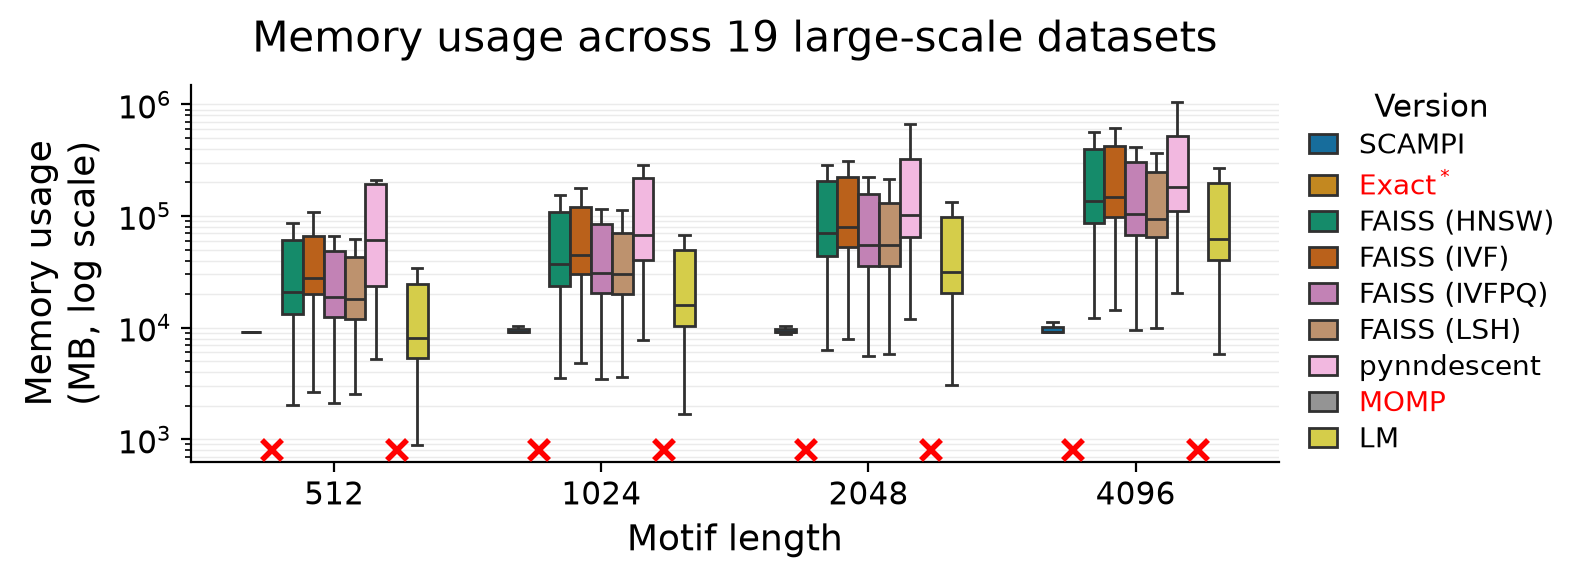

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_df, all_x, all_versions, missing = get_missing_combinations(
    df=filtered_df,
    x_col="motif length",
    hue_col="version",
    y_col="memory in MB",
    x_order=sorted(filtered_df["motif length"].dropna().unique()),
    hue_order=version_order,
)

box_width = 0.7

sns.boxplot(
    data=plot_df,
    x="motif length",
    y="memory in MB",
    hue="version",
    order=all_x,
    hue_order=all_versions,
    # palette=palette,
    palette=version_colors,
    width=box_width,
    linewidth=1.0,
    showfliers=False,
    ax=ax,
)

ax.set_yscale("log")

ax.set_xlabel("Motif length", fontsize=13)
ax.set_ylabel("Memory usage\n(MB, log scale)", fontsize=13)

n_datasets = filtered_df["dataset"].nunique()
ax.set_title(
    f"Memory usage across {n_datasets} large-scale datasets",
    fontsize=15,
    pad=12,
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
)

ax.grid(
    axis="y",
    which="both",
    linewidth=0.5,
    alpha=0.25,
)

add_missing_x_markers(
    ax=ax,
    missing=missing,
    x_order=all_x,
    hue_order=all_versions,
    group_width=box_width,
    y_fraction=0.03,
)

handles, labels = ax.get_legend_handles_labels()

leg = ax.legend(
    handles=handles,
    labels=labels,
    title="Version",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=10,
    title_fontsize=11,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.3,
    frameon=False,
)

color_missing_legend_labels(
    legend=leg,
    missing=missing,
    color="red",
)

sns.despine(ax=ax)
fig.tight_layout()

fig.savefig(
    "images/boxplot_memory.pdf",
    bbox_inches="tight",
)

plt.show()

In [8]:
filtered_df.dropna(subset="memory in MB") \
    .pivot_table(
        values=["memory in MB"], 
        index=["version"], 
        columns=["motif length"], 
        aggfunc='median')

memory in MB                             
motif length          512      1024      2048      4096
version                                                
FAISS (HNSW)       21045.0  37465.2   70240.1  135821.2
FAISS (IVF)        28114.0  44878.3   80435.7  149138.7
FAISS (IVFPQ)      18680.9  30999.8   55583.9  104793.6
FAISS (LSH)        17900.6  30341.2   55195.4   94602.9
LM                  8104.7  15894.5   31418.3   62392.5
SCAMPI              9160.3   9160.3    9164.9    9170.5
pynndescent        60457.2  67800.9  102320.9  180830.8

In [9]:
filtered_df.dropna(subset="relative extent") \
    .pivot_table(
        values=["relative extent"],
        index=["version"],
        columns=["motif length"], 
        aggfunc='mean')

relative extent                  
motif length             512   1024  2048  4096
version                                        
FAISS (HNSW)             94.8  96.3  84.7  78.5
FAISS (IVF)              94.8  91.1  84.7  69.8
FAISS (IVFPQ)            93.3  87.5  73.2  64.3
FAISS (LSH)              79.1  80.5  84.0  67.9
MOMP                      9.5  27.4  25.6  30.9
SCAMPI                   94.1  92.9  90.1  94.7
pynndescent              89.5  86.0  81.4  83.6

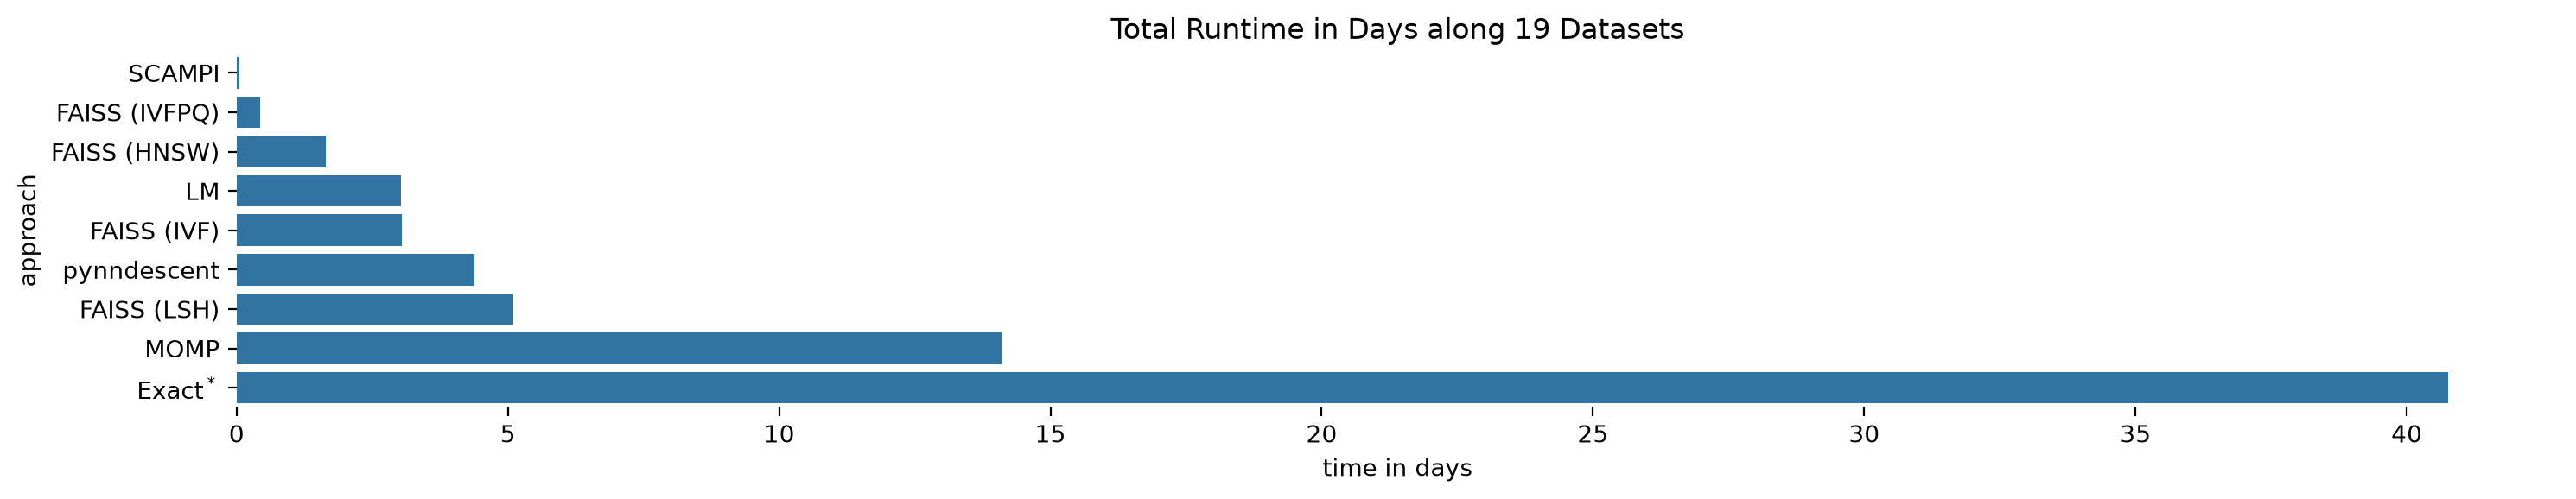

In [10]:
subset = filtered_df.copy().dropna(subset="time in s")
subset = subset[subset["motif length"]<4096]
subset["time in s"] = subset["time in s"] / 3600 / 24
subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
subset = subset.groupby("approach").agg({"time in days":"sum"})
order = subset.sort_values("time in days").index

plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="time in days", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

# display(subset[["time in days"]])

plt.title(f"Total Runtime in Days along {filtered_df.dataset.nunique()} Datasets")
plt.tight_layout()
plt.savefig("images/all_runtime.pdf", bbox_inches='tight')
plt.show()

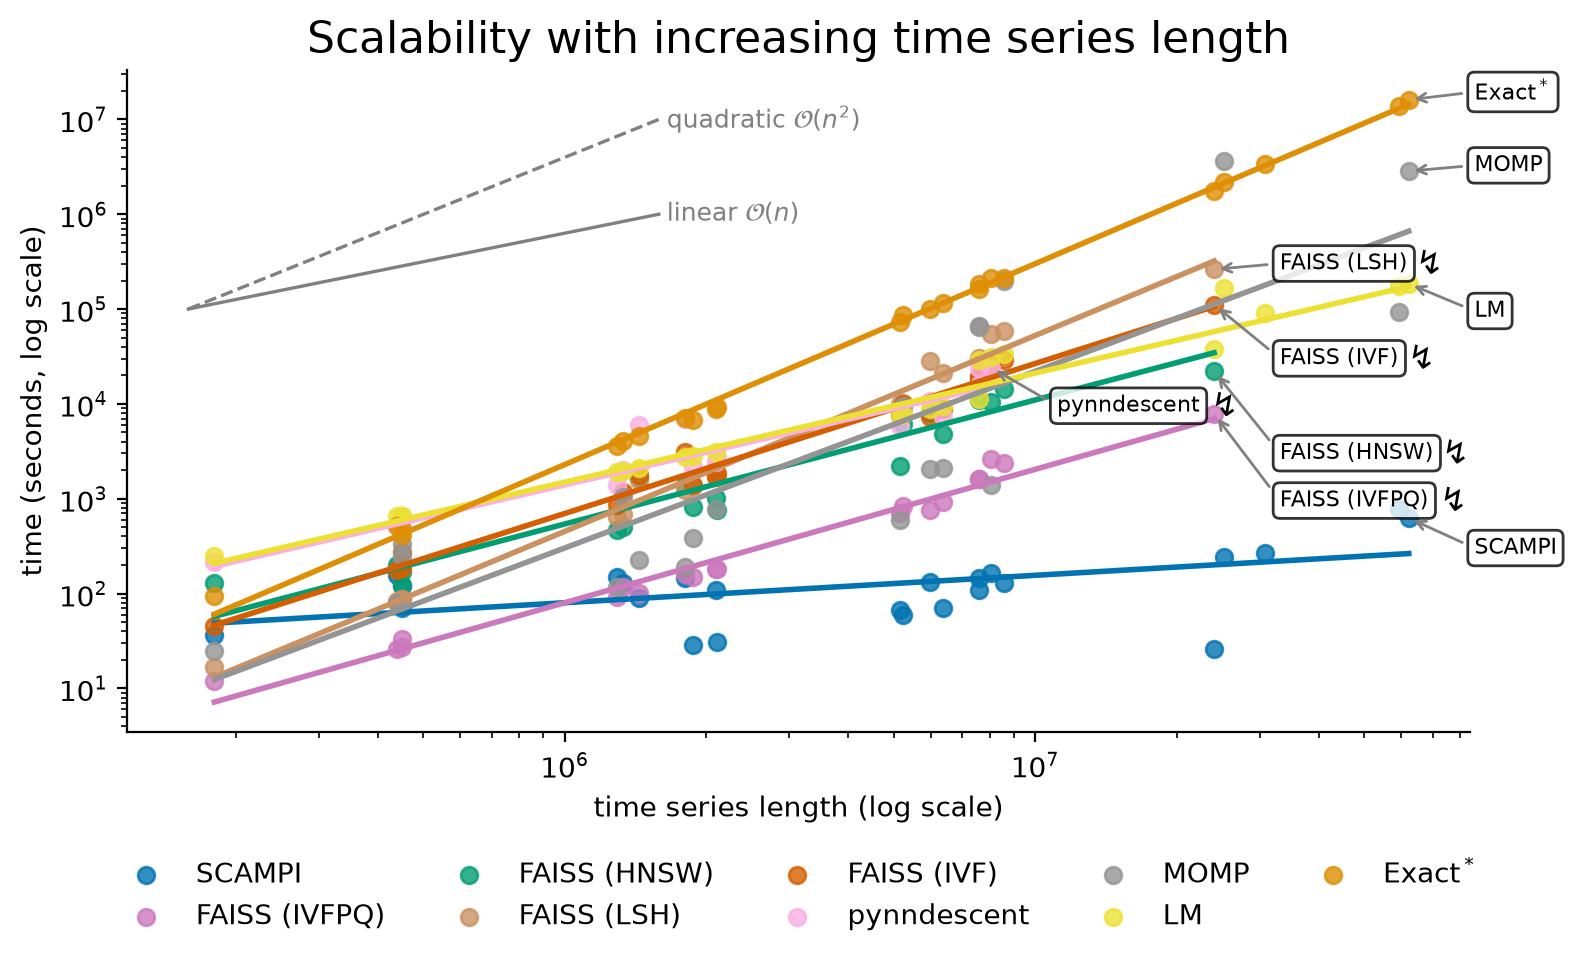

In [11]:
custom_order = [
    "SCAMPI",
    "FAISS (IVFPQ)",
    "FAISS (HNSW)",
    "FAISS (LSH)",
    "FAISS (IVF)",
    "pynndescent",
    "MOMP",
    "LM",
    "Exact$^*$",
]

subset = df_all.copy()
subset = subset[subset["motif length"] == 2048]
subset = subset[subset["version"].isin(custom_order)].copy()

subset["log length"] = np.log10(subset["length"].astype(np.float64))
subset["log time in s"] = np.log10(subset["time in s"].astype(np.float64))

# palette = sns.color_palette("tab10", n_colors=len(custom_order))

fig, ax = plt.subplots(figsize=(8, 5))

for i, order in enumerate(custom_order):
    df_order = subset[subset["version"] == order].copy()
    if df_order.empty:
        continue

    color = version_colors[order]
    
    # Only fit a regression if enough points are available
    fit_reg = len(df_order) >= 2

    sns.regplot(
        data=df_order,
        x="log length",
        y="log time in s",
        label=order,
        ci=None,
        scatter=True,
        fit_reg=fit_reg,
        robust=fit_reg,
        truncate=True,
        scatter_kws={"color": color},
        line_kws={"color": color, "linewidth": 2},
        ax=ax,
    )

annotations = []
for order in custom_order:
    df_order = subset[subset["version"] == order].sort_values("length")
    if not df_order.empty:
        last_point = df_order.iloc[-1]
        x_last = float(last_point["log length"])
        y_last = float(last_point["log time in s"])
        annotations.append((y_last, x_last, order))

annotations = sorted(annotations, reverse=True)

spacing = 0.5
last_y = np.inf
texts = []

# Make sure limits exist before using them for annotation offsets
fig.canvas.draw()
xrange_ = ax.get_xlim()[1] - ax.get_xlim()[0]

for y, x, label in annotations:
    annoty = last_y - spacing if (last_y - y) < spacing else y
    last_y = annoty

    text = ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + 0.05 * xrange_, annoty),
        ha="left",
        fontsize=8,
        color="black",
        weight="normal",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        arrowprops=dict(arrowstyle="->", color="gray", relpos=(0.0, 0.5)),
    )
    texts.append(text)

# Y-axis ticks
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([fr"$10^{{{int(t)}}}$" for t in yticks])

minor_yticks = []
for major in yticks[:-1]:
    if np.isfinite(major):
        minor_yticks.extend(np.log10(np.arange(2, 10) * 10 ** major))
ax.set_yticks(minor_yticks, minor=True)
ax.set_yticklabels([], minor=True)

# X-axis ticks
xticks = [5, 6, 7, 8]
ax.set_xticks(xticks)
ax.set_xticklabels([fr"$10^{{{t}}}$" for t in xticks])

minor_xticks = []
for major in xticks[:-1]:
    minor_xticks.extend(np.log10(np.arange(2, 10) * 10 ** major))
ax.set_xticks(minor_xticks, minor=True)
ax.set_xticklabels([], minor=True)

sns.despine(top=True, left=False, right=True)

ax.set_title("Scalability with increasing time series length", fontsize=16)
ax.set_xlabel("time series length (log scale)")
ax.set_ylabel("time (seconds, log scale)")

# Use only one ncol argument
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=min(len(custom_order), 5),
    frameon=False,
)

# Reference slope lines
anchor_x, anchor_y = 5.2, 5.0
dx = 1.0

# Linear: slope 1
ax.plot(
    [anchor_x, anchor_x + dx],
    [anchor_y, anchor_y + dx],
    color="gray",
    linewidth=1.2,
    linestyle="-",
)
ax.text(
    anchor_x + dx,
    anchor_y + dx,
    r" linear $\mathcal{O}(n)$",
    va="center",
    ha="left",
    fontsize=9,
    color="gray",
)

# Quadratic: slope 2
ax.plot(
    [anchor_x, anchor_x + dx],
    [anchor_y, anchor_y + 2 * dx],
    color="gray",
    linewidth=1.2,
    linestyle="--",
)
ax.text(
    anchor_x + dx,
    anchor_y + 2 * dx,
    r" quadratic $\mathcal{O}(n^2)$",
    va="center",
    ha="left",
    fontsize=9,
    color="gray",
)

plt.tight_layout()

# Add markers after rendering so bbox is available
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

for text in ax.texts:
    if text.get_text().startswith("FAISS") or text.get_text() == "pynndescent":
        bbox_display = text.get_window_extent(renderer=renderer)
        bbox_data = ax.transData.inverted().transform(bbox_display)

        # Safer than emoji for PDF export
        ax.text(
            bbox_data[1, 0],
            bbox_data[0, 1] + 0.1,
            # r" $\lightning$",
            " ↯",
            ha="left",
            va="center",
            fontsize=12,
        )

plt.savefig("images/scalability.pdf", bbox_inches="tight")
plt.show()

,length,motif length,backend,time in s,memory in MB,extent,motiflet,elbows,dataset,version,sampling
3,1875227,4096,SCAMPI,1.0e+02,9274.5,36.1,[ 933693 1452823 426038 1615589 447406 10971...,[array([7])],HAR_Ambient_Sensor_Data,SCAMPI,NaN
11,1439997,4096,SCAMPI,1.0e+02,9143.4,40.8,[ 239100 1324489 348217 223080 686379 9172...,"[array([4, 6])]",EOG_one_hour_400_Hz,SCAMPI,NaN
15,6375000,4096,SCAMPI,6.6e+01,9165.6,0.0,[4823201 4826201 4829201 4832201 4835201 48382...,[array([2])],CinC_Challenge,SCAMPI,NaN
19,2100777,4096,SCAMPI,1.2e+02,9342.2,14.0,[ 857304 576741 340351 938085 1191230 1389...,[array([4])],water,SCAMPI,NaN
23,1799997,4096,SCAMPI,1.2e+02,9191.0,15.8,[1264039 668396 537756 1433523 1582499 10828...,[array([2])],Challenge2009Respiration500HZ,SCAMPI,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1125,23999997,4096,scalable (subsampling=16),1.9e+06,NaN,NaN,[23126736 8982576 14633616 23239216 11927056 ...,[2],FingerFlexionECoG,Exact$^*$,16
1129,1288330,4096,scalable (subsampling=16),4.0e+03,NaN,NaN,[1119344 853344 329360 744896 47840 11768...,[7],BlackLeggedKittiwake,Exact$^*$,16
1133,180000,4096,scalable (subsampling=16),9.9e+01,NaN,NaN,[ 59376 80048 66656 141472 11776 153920 164...,[2],EOG_one_hour_50_Hz,Exact$^*$,16
1137,5983000,4096,scalable (subsampling=16),1.0e+05,NaN,NaN,[3721584 5191088 2609328 8672 2009360 59227...,[8],MGHSleepElectromyography,Exact$^*$,16


,time in days,extent,speedup
approach,,,
SCAMPI,2.5e-02,15.6,1.0
pynndescent,2.4e+00,15.5,94.9
FAISS (HNSW),3.0e+00,16.9,119.5
MOMP,5.3e+00,28.4,212.6
FAISS (IVF),5.8e+00,16.9,232.6
FAISS (LSH),6.8e+00,17.8,270.8
LM,7.5e+00,NaN,300.2
Exact$^*$,3.7e+01,NaN,1475.2


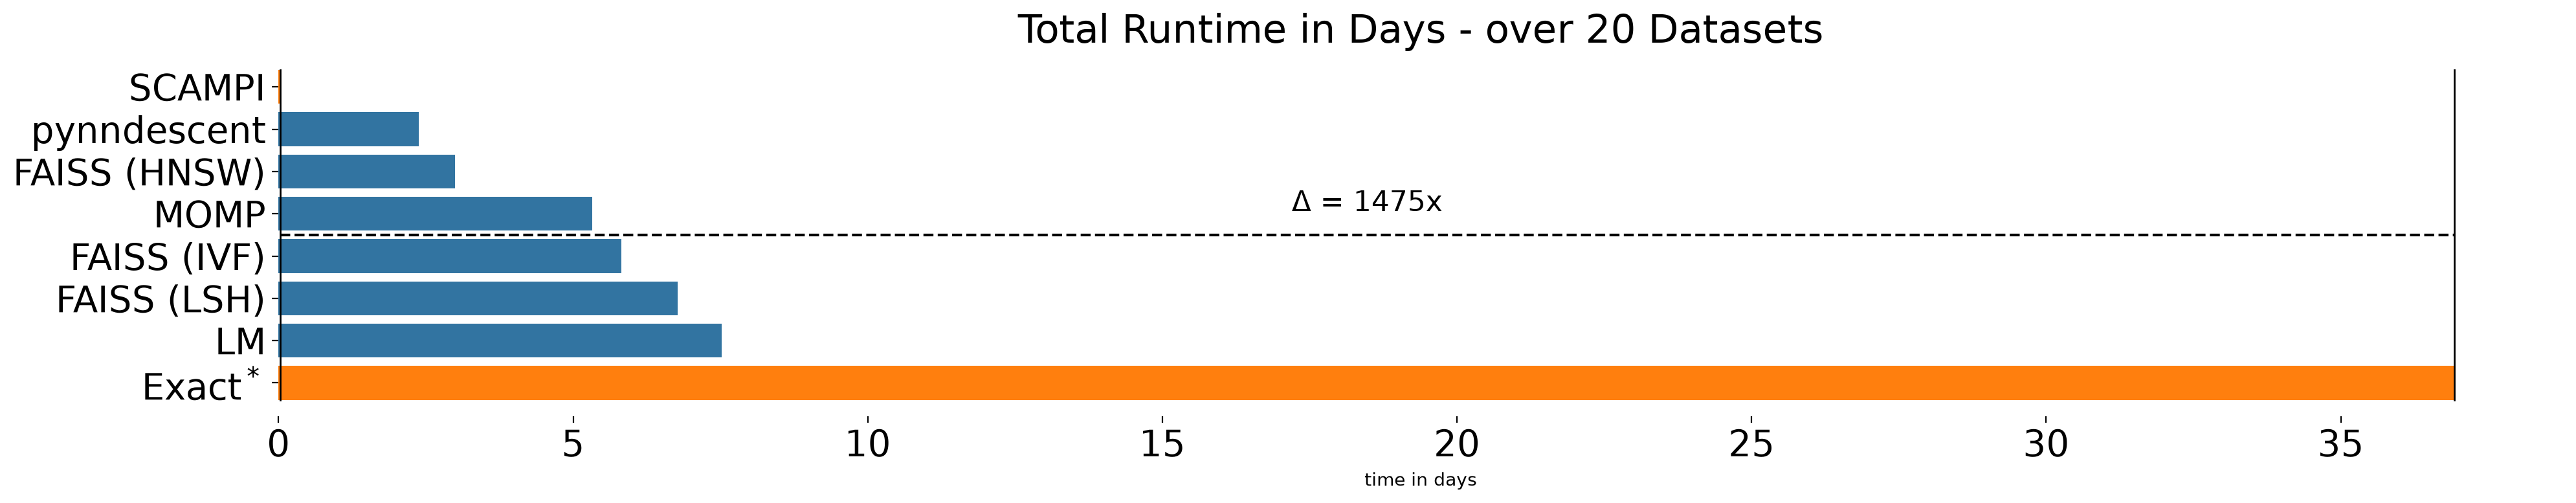

In [12]:
def plot(datasets, length=4096):
    custom_order = ["SCAMPI", 
                    "FAISS (HNSW)",
                    "FAISS (LSH)",
                    "FAISS (IVF)",
                    "pynndescent",
                    "MOMP",
                    "LM",
                    "Exact$^*$"  
                   ]
    
    filtered_df = df_all[df_all["dataset"].isin(datasets)]
    filtered_df = filtered_df[df_all.version.isin(custom_order)]    
    filtered_df = filtered_df[filtered_df["motif length"] == length]

    display(filtered_df)
    
    subset = filtered_df.copy()
    subset["time in s"] = subset["time in s"] / 3600 / 24
    subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
    subset = subset.groupby("approach").agg({"time in days" : "sum", "extent" : "median"})
    order = subset.sort_values("time in days").index
    
    fig, ax = plt.subplots(figsize=(20,4))
    sns.barplot(y="approach", x="time in days", data=subset, order = order, ax = ax)
    sns.despine(top=True, left=True, right=True, bottom=True)
    
    ax = plt.gca() 
    bars = ax.patches
    first_bar = bars[0]
    last_bar = bars[-1]
    first_bar.set_facecolor("#ff7f0e")
    last_bar.set_facecolor("#ff7f0e")
    
    v1 = first_bar.get_width() 
    v2 = last_bar.get_width()
    y_top = last_bar.get_y() + last_bar.get_height()
    y_bottom = first_bar.get_y()
    y_center = (y_top + y_bottom) / 2
    
    ax.plot([v1, v2], [y_center, y_center], color="black", linestyle="--", linewidth=1.5, zorder=3)
    ax.plot([v1, v1], [y_bottom, y_top], color="black", linestyle="-", linewidth=1.0, zorder=3)
    ax.plot([v2, v2], [y_bottom, y_top], color="black", linestyle="-", linewidth=1.0, zorder=3)

    max_d = subset["time in days"].max()
    min_d = subset["time in days"].min()

    speedup = subset.transform (lambda l: l / l.min())
    subset["speedup"] = speedup["time in days"]
    subset = subset.sort_values("time in days", ascending=False)

    display(subset.sort_values("speedup"))
    factor = max_d / min_d
    ax.text((v1 + v2) / 2, y_center-0.4, f"Δ = {factor:.0f}x",
                ha="center", va="bottom", fontsize=16, zorder=4)
    
    n_datasets = filtered_df.dataset.nunique()
    # plt.xscale('log')

    plt.xticks(fontsize=20)
    ax.set_ylabel("")
    plt.yticks(fontsize=20)
    if len(datasets) > 1:
        plt.title(f"Total Runtime in Days - over {n_datasets} Datasets", fontsize=22)
    else: 
        plt.title(f"Runtime in Days - {datasets[0]}", fontsize=22)
    plt.tight_layout()

plot(datasets_to_keep)
plt.savefig("images/runtime_total.pdf", bbox_inches='tight')
plt.show()


In [13]:
# df_all[(df_all.version == "Exact$^*$") & (df_all.length > 10**6)].sort_values("length")# ["time in s"] # / 3600 #  / 24

,time in days,extent,speedup
approach,,,
Exact$^*$,2.2e+01,NaN,65266.2
FAISS (LSH),3.0e+00,2.9e+01,9030.5
LM,1.8e+00,NaN,5255.5
FAISS (IVF),1.3e+00,2.6e+01,3837.5
FAISS (HNSW),6.6e-01,2.6e+01,1976.0
MOMP,5.3e-01,9.1e+01,1587.7
SCAMPI,3.4e-04,3.4e-02,1.0


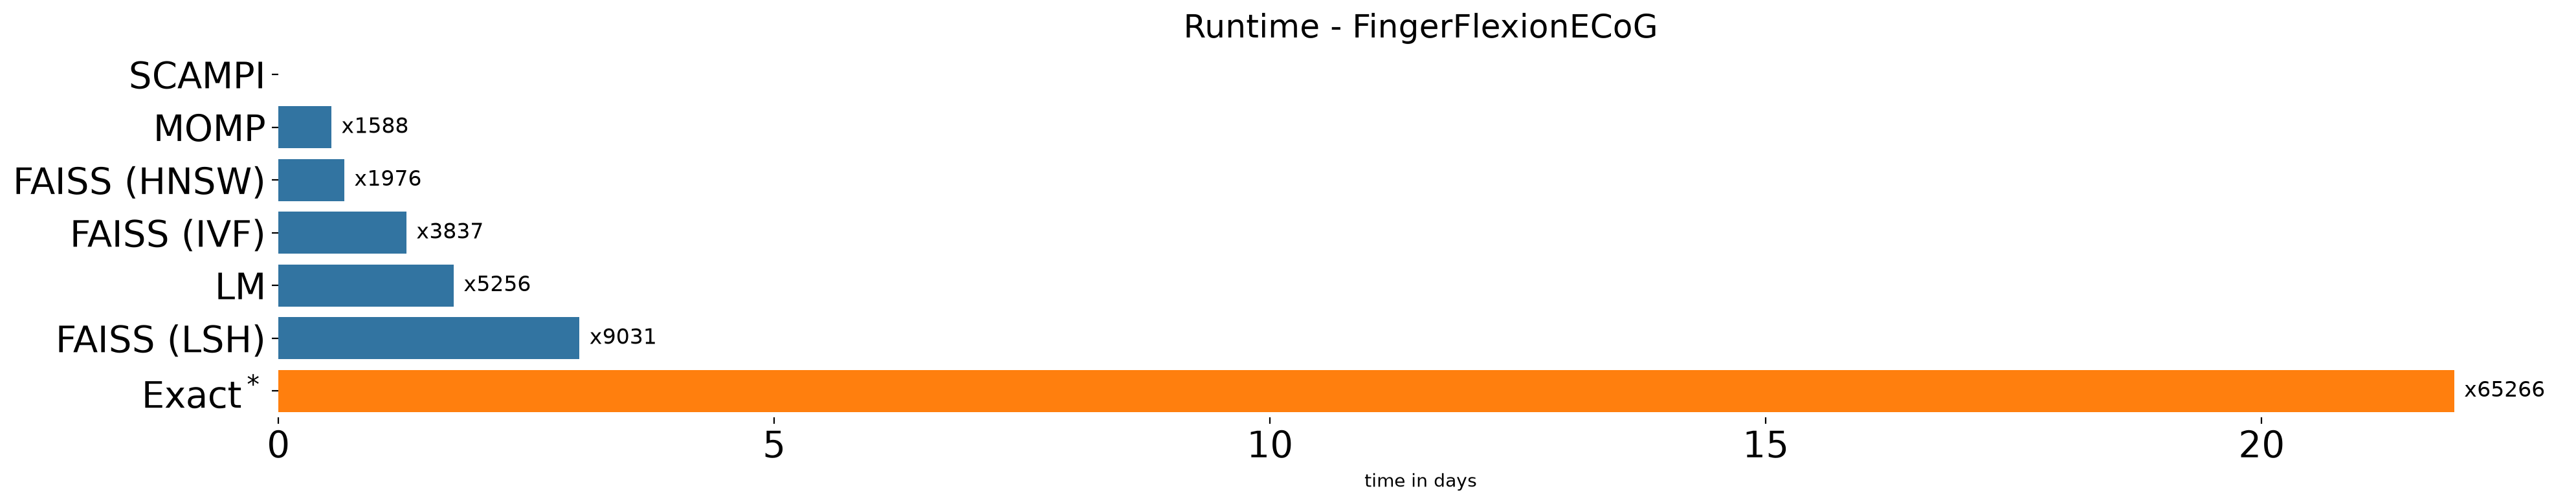

In [14]:
def plot2(datasets, length=4096):
    custom_order = ["SCAMPI",
                    "FAISS (HNSW)",
                    "FAISS (LSH)",
                    "FAISS (IVF)",
                    "FAISS (IVFPQ)",
                    "pynndescent",
                    "MOMP",
                    "LM",
                    "Exact$^*$"  
                   ]
    
    filtered_df = df_all[df_all["dataset"].isin(datasets)]
    filtered_df = filtered_df[df_all.version.isin(custom_order)]    
    filtered_df = filtered_df[filtered_df["motif length"] == length]
    
    subset = filtered_df.copy()
    subset["time in s"] = subset["time in s"] / 3600 / 24
    subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
    subset = subset.groupby("approach").agg({"time in days" : "sum", "extent" : "median"})
    order = subset.sort_values("time in days").index

    fig, ax = plt.subplots(figsize=(20,4))
    sns.barplot(y="approach", x="time in days", data=subset, order = order, ax = ax)
    sns.despine(top=True, left=True, right=True, bottom=True)
    
    ax = plt.gca() 
    bars = ax.patches
    first_bar = bars[0]
    last_bar = bars[-1]
    first_bar.set_facecolor("#ff7f0e")
    last_bar.set_facecolor("#ff7f0e")
    
    speedup = subset.transform (lambda l: l / l.min())
    subset["speedup"] = speedup["time in days"]
    subset = subset.sort_values("time in days", ascending=False)

    display(subset)
    
    # Annotate each bar with its speedup value
    for bar, speed in zip(ax.patches[1:], reversed(subset["speedup"].iloc[:-1])):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(
            width + 0.1, y,  # 0.1 units offset right from bar end
            f"x{speed:.0f}",
            va='center', ha='left',
            fontsize=12,
            color='black'
        )
        
    n_datasets = filtered_df.dataset.nunique()

    plt.xticks(fontsize=20)
    ax.set_ylabel("")
    plt.yticks(fontsize=20)
    if len(datasets) > 1:
        plt.title(f"Total Runtime in Days - over {n_datasets} Datasets", fontsize=18)
    else: 
        plt.title(f"Runtime - {datasets[0]}", fontsize=18)
    plt.tight_layout()

plot2(["FingerFlexionECoG"], length=4096)
plt.savefig("images/FingerFlexionECoG.pdf", bbox_inches='tight')
plt.show()